## HOUSE PRICE PREDICTION 


In [30]:
#importing neccssary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("successfully imported ")

successfully imported 


Loading data set from excel

In [31]:
data = pd.read_excel("Housing.csv.xlsx")
data.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,prices
0,7229300521,20141013T000000,2,1.00,1180,5650,1.0,0,0,3,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,231300
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,538000
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,0,0,3,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,180000
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,604000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,510000


In [32]:
data.shape

(21613, 21)

In [33]:
data.columns

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'prices'],
      dtype='object')

In [34]:
data.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,prices
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04
mean,4.580306e+09,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,5.400886e+05
std,2.876570e+09,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,3.671268e+05
min,1.000102e+06,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,7.500000e+04
25%,2.123049e+09,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,3.219500e+05
50%,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,4.500000e+05
75%,7.308900e+09,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,6.450000e+05
max,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06


In [35]:
data.isnull().sum()

id               0
date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
prices           0
dtype: int64

In [36]:
data.duplicated().sum()

np.int64(0)

## Explorative Data Analysis  
  
#  Distribution   
step 1:  
- Analysing the distribution of actual features from Data set  
- Using Histogram for visualization
- By using figure , axes I created multiple plots in a row and column  
- instead of visualizing all in seperate plots visualizing all in one frame is best approach and comparing them makes easy

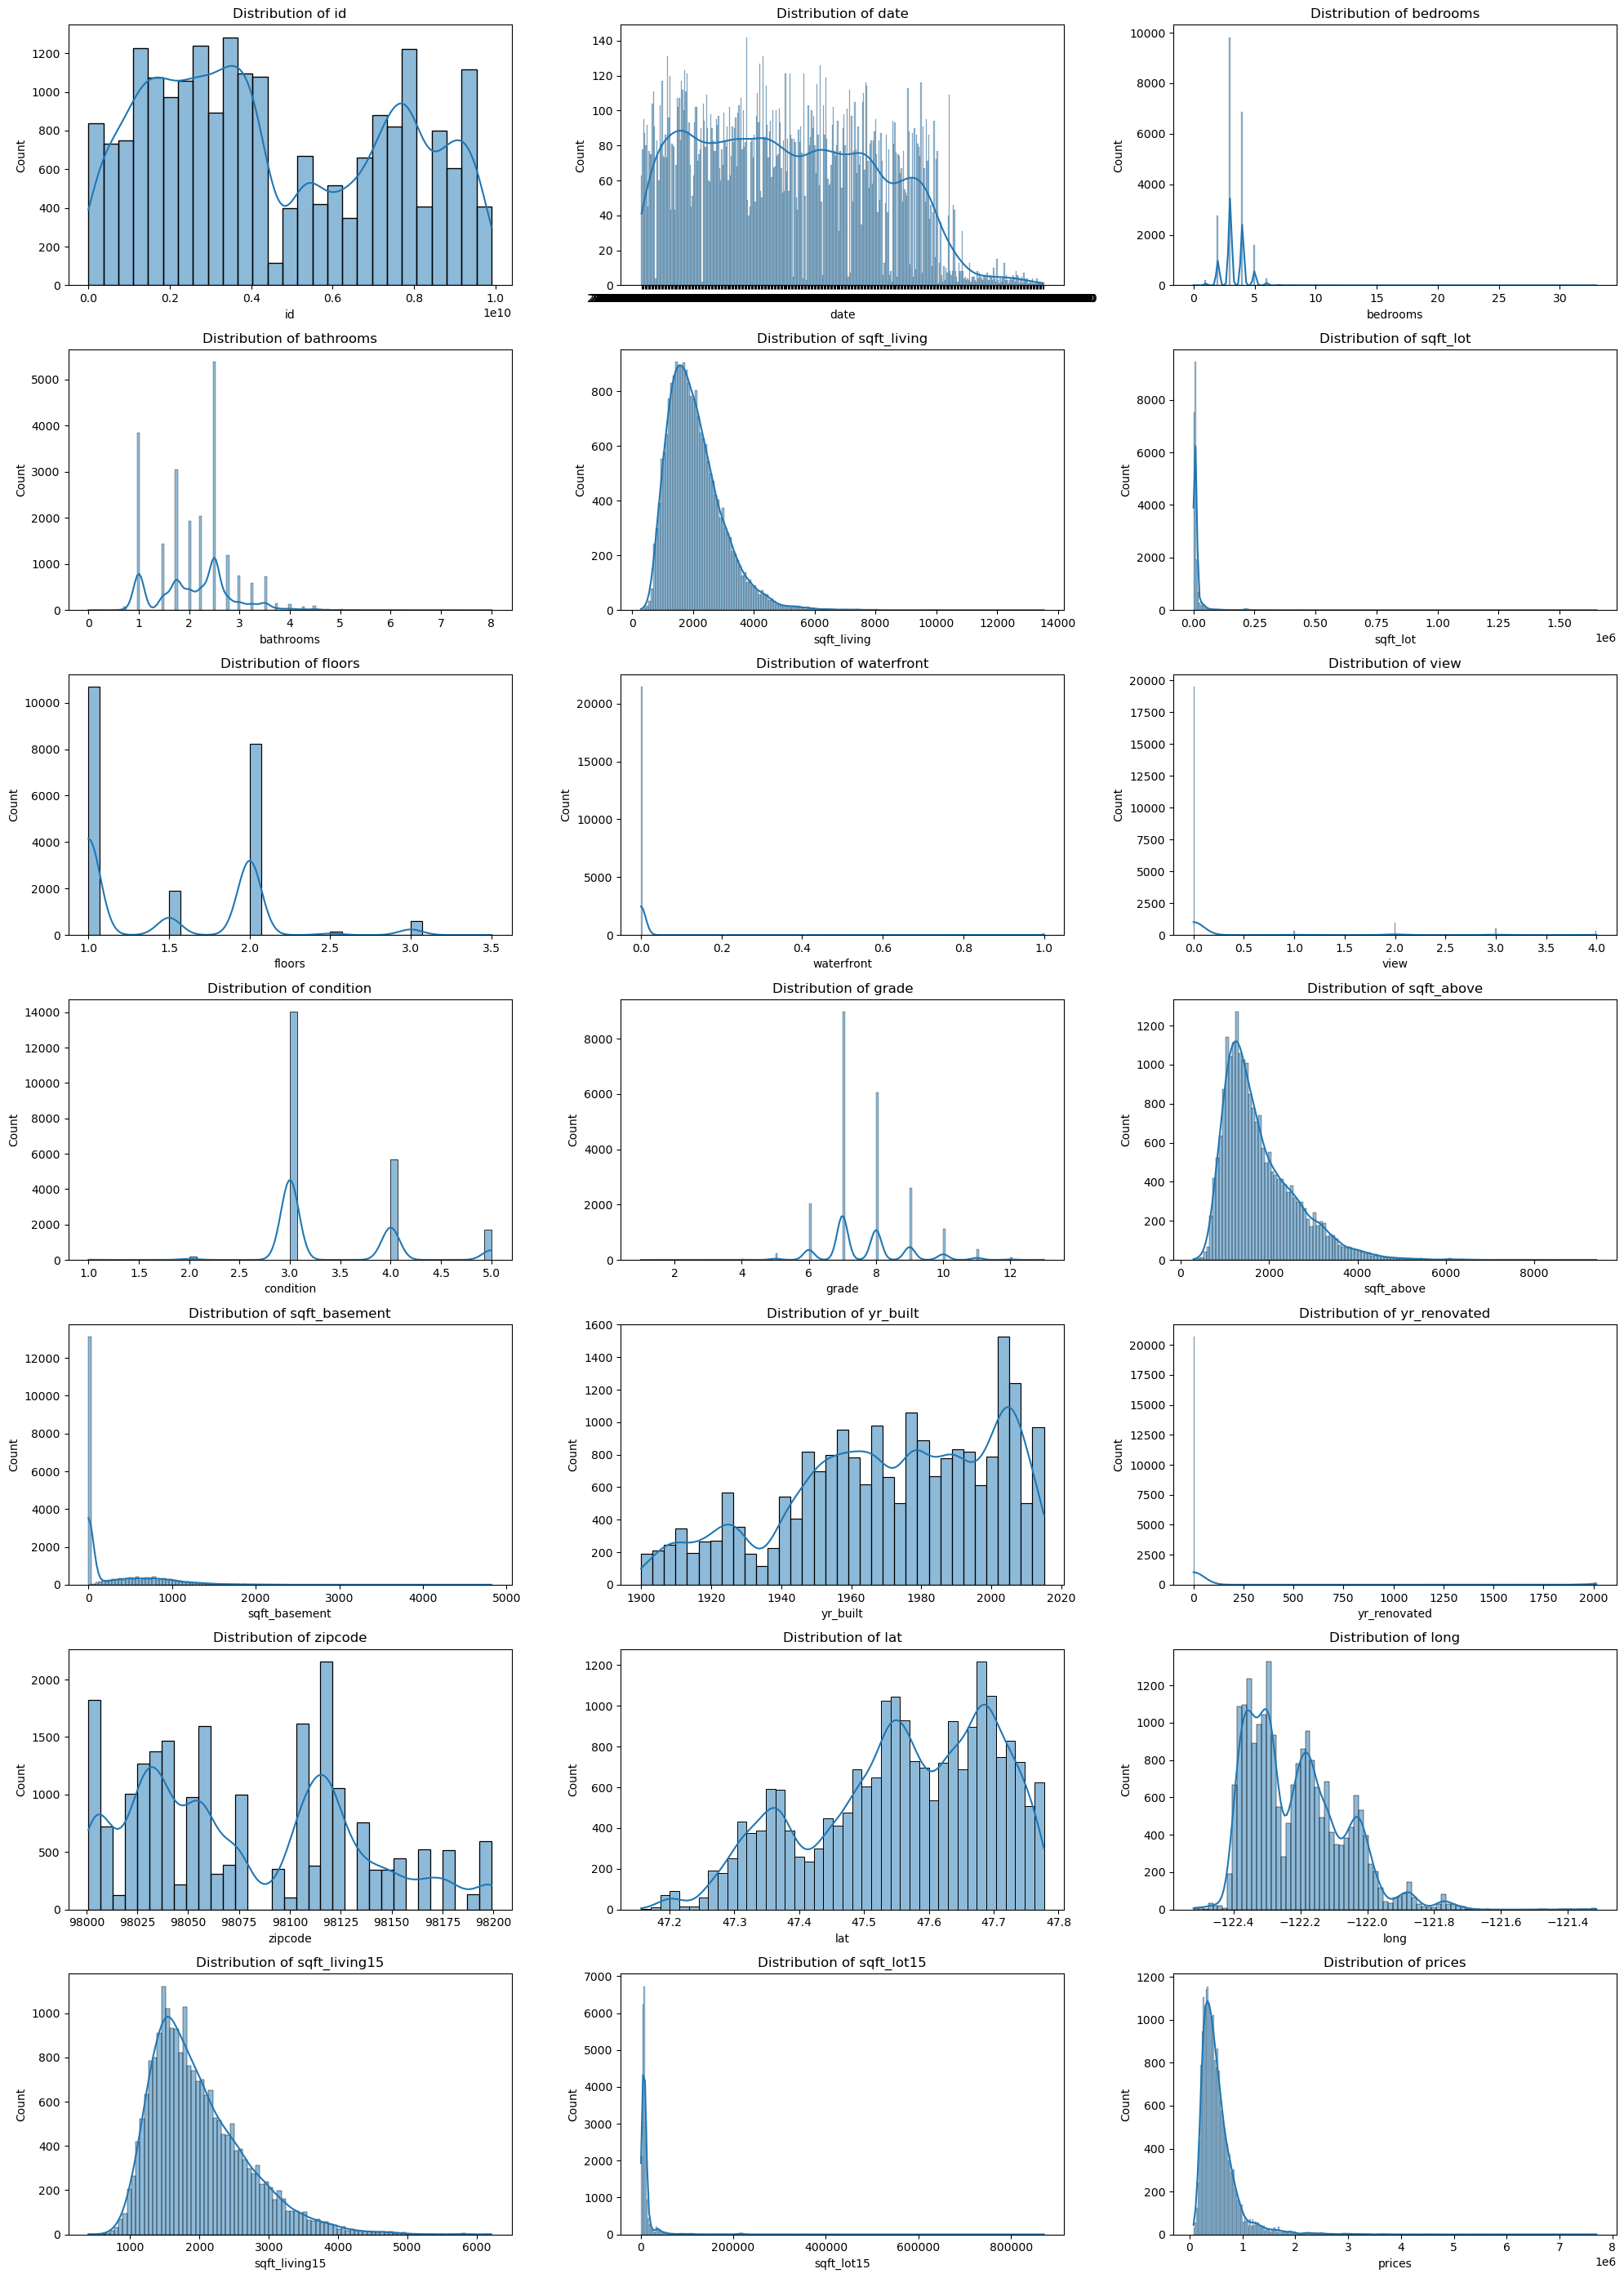

In [37]:
#distributing the features
num_columns =data.select_dtypes(include='number')

items = data.columns
n_features = len(items)
n_cols = 3
n_rows =(n_features + n_cols - 1)//n_cols

fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,4*n_rows),dpi=100)
axes = axes.flatten()


for i,item in enumerate(items):
    sns.histplot(data[item],kde=True,ax = axes[i])
    axes[i].set_title(f"Distribution of {item}")

for j in range(len(items),len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


# Understanding the Skew  
  
step 2 :-
- Analysing the skewness of each features to identify the How much it skewed  
like if it is greater than 0 it is right skeewed  
if it is less than 0 than it is left skewed  
else if it is 0 than it is a exact distribution  

### understanding skew helps in increase performance of model 

In [38]:
num_cols = data.select_dtypes(include='number')

skewness = data[num_cols.columns].skew().sort_values(ascending=False)
print(skewness)




sqft_lot         13.060019
waterfront       11.385108
sqft_lot15        9.506743
yr_renovated      4.549493
prices            4.024080
view              3.395750
bedrooms          1.974028
sqft_basement     1.577965
sqft_living       1.471555
sqft_above        1.446664
sqft_living15     1.108181
condition         1.032805
long              0.885053
grade             0.771103
floors            0.616177
bathrooms         0.511108
zipcode           0.405661
id                0.243327
yr_built         -0.469805
lat              -0.485270
dtype: float64


# Log transformation  

Step 3 :-
- Log transformation is used to reduce skewness, handle large values, and make data closer to a normal distribution, which helps machine learning models perform better. 

In [39]:
import numpy as np

# Columns that usually need log transformation
log_cols = [
    'sqft_lot',
    'sqft_lot15',
    'sqft_living',
    'sqft_living15',
    'sqft_above',
    'sqft_basement',
    'prices'
]

# Apply transformation only if column exists
for col in log_cols:
    if col in data.columns:
        data[col] = np.log1p(data[col])
        print(f"{col} transformed successfully")
    else:
        print(f"{col} not found in dataset")

# Rename target variable if it exists
if 'prices' in data.columns:
    data.rename(columns={'prices': 'price_log'}, inplace=True)

# Select numeric columns
num_cols = data.select_dtypes(include='number')

# Calculate skewness
skewness = data[num_cols.columns].skew().sort_values(ascending=False)

print("\nSkewness after transformation:\n")
print(skewness)


sqft_lot transformed successfully
sqft_lot15 transformed successfully
sqft_living transformed successfully
sqft_living15 transformed successfully
sqft_above transformed successfully
sqft_basement transformed successfully
prices transformed successfully

Skewness after transformation:

waterfront       11.385108
yr_renovated      4.549493
view              3.395750
bedrooms          1.974028
condition         1.032805
sqft_lot15        0.967255
sqft_lot          0.962893
long              0.885053
grade             0.771103
floors            0.616177
bathrooms         0.511108
sqft_basement     0.484603
price_log         0.428092
zipcode           0.405661
sqft_above        0.254034
id                0.243327
sqft_living15     0.206964
sqft_living      -0.034727
yr_built         -0.469805
lat              -0.485270
dtype: float64


# After log transformation finally Target variable 

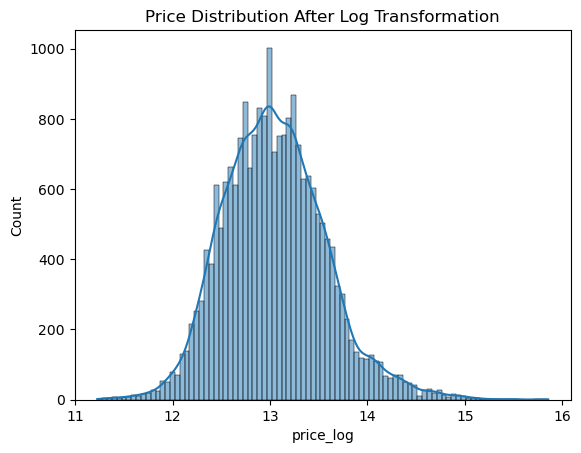

In [40]:
sns.histplot(data['price_log'], kde=True)
plt.title("Price Distribution After Log Transformation")
plt.show()

In [41]:
data.columns

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'price_log'],
      dtype='object')

# Outliers Dectection 
  
  Using IQR (Inter-quartile-range)  
  - Finding the upper_bound and Lower_bound 
  - Atlast showing the percentage 


In [42]:
# Select numerical columns only
num_cols = data.select_dtypes(include='number')

# Display outlier percentage for each column
def detect_outliers(num_cols):
    outliers_info = {}
    for col in num_cols.columns:
        Q1 = num_cols[col].quantile(0.25)
        Q3 = num_cols[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = num_cols[(num_cols[col] < lower_bound) | (num_cols[col] > upper_bound)]
        outlier_percentage = (len(outliers) / len(num_cols)) * 100

        print(f"{col} → Outliers: {len(outliers)} rows ({outlier_percentage:.2f}%)")

        # store info for this column
        outliers_info[col] = {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_percentage': outlier_percentage
        }
    return outliers_info

outliers_info = detect_outliers(num_cols)

id → Outliers: 0 rows (0.00%)
bedrooms → Outliers: 546 rows (2.53%)
bathrooms → Outliers: 571 rows (2.64%)
sqft_living → Outliers: 110 rows (0.51%)
sqft_lot → Outliers: 2555 rows (11.82%)
floors → Outliers: 0 rows (0.00%)
waterfront → Outliers: 163 rows (0.75%)
view → Outliers: 2124 rows (9.83%)
condition → Outliers: 30 rows (0.14%)
grade → Outliers: 1911 rows (8.84%)
sqft_above → Outliers: 51 rows (0.24%)
sqft_basement → Outliers: 0 rows (0.00%)
yr_built → Outliers: 0 rows (0.00%)
yr_renovated → Outliers: 914 rows (4.23%)
zipcode → Outliers: 0 rows (0.00%)
lat → Outliers: 2 rows (0.01%)
long → Outliers: 256 rows (1.18%)
sqft_living15 → Outliers: 78 rows (0.36%)
sqft_lot15 → Outliers: 2492 rows (11.53%)
price_log → Outliers: 333 rows (1.54%)


# CORELATION MATRIX  

- Using heat map analysing the relation betwwen target and Features 

price_log        1.000000
grade            0.703636
sqft_living      0.674940
sqft_living15    0.607200
sqft_above       0.586323
bathrooms        0.550799
lat              0.449175
view             0.346523
bedrooms         0.343611
floors           0.310556
sqft_basement    0.236384
waterfront       0.174587
sqft_lot         0.137733
sqft_lot15       0.123000
yr_renovated     0.114498
yr_built         0.080653
long             0.049941
condition        0.039555
id              -0.003818
zipcode         -0.038299
Name: price_log, dtype: float64


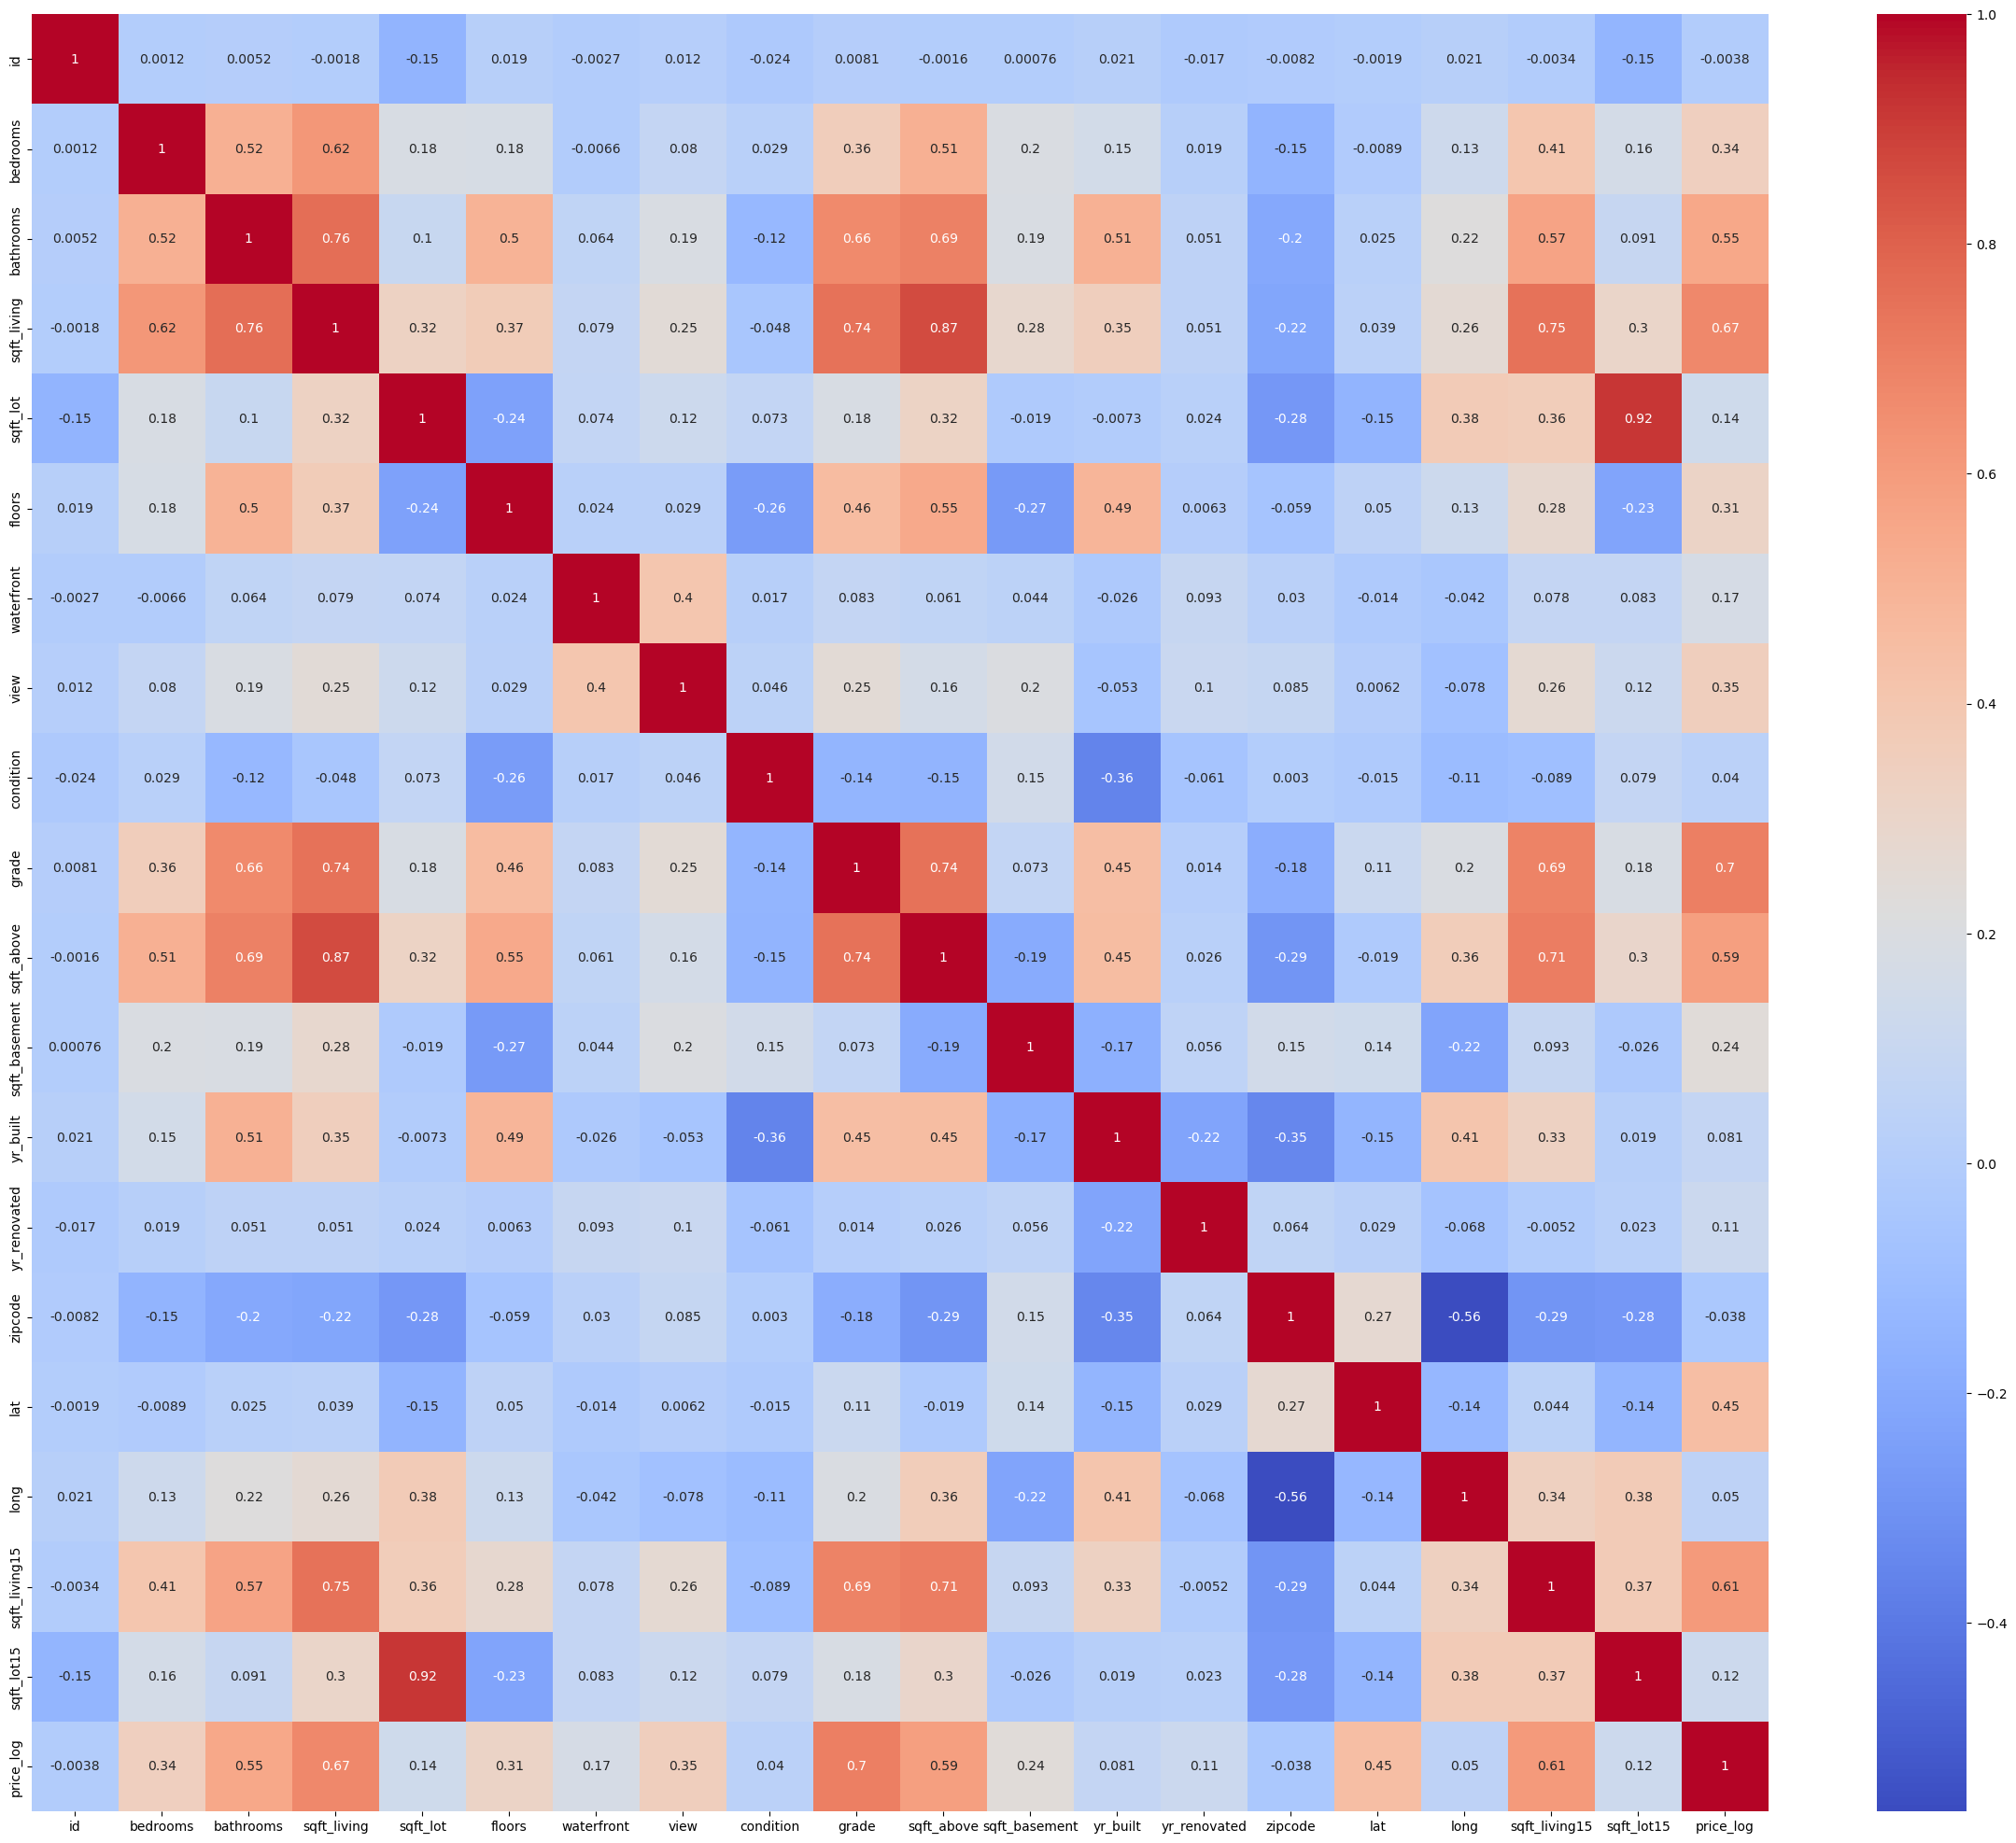

In [43]:
# select numeric columns only
num_data = data.select_dtypes(include='number')

# correlation with price
print(num_data.corr()['price_log'].sort_values(ascending=False))

# heatmap
plt.figure(figsize=(30,25))
sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm")
plt.show()

# showing the best featues according to heatmap 

price_log        1.000000  
grade            0.703636  
sqft_living      0.674940  
sqft_living15    0.607200    
sqft_above       0.586323  
bathrooms        0.550799  
lat              0.449175  
view             0.346523  
bedrooms         0.343611  
floors           0.310556  
sqft_basement    0.236384  
waterfront       0.174587  
sqft_lot         0.137733  
sqft_lot15       0.123000  
yr_renovated     0.114498  
yr_built         0.080653  
long             0.049941  
condition        0.039555  
id              -0.003818  
zipcode         -0.038299  


# Handing outliers  
- using remove
- cap
- log

In [44]:
# #handling outliers 
num_cols = data.select_dtypes(include='number')

def handling_outliers(data, outliers_info):
    for col, info in outliers_info.items():
        lower = info['lower_bound']
        upper = info['upper_bound']
        percentage = info['outlier_percentage']
        if percentage < 5:
            #Remove outliers
            data = data[(data[col] >= lower) & (data[col] <= upper)]
            print(f"{col}: Outliers removed")
        elif 5 <= percentage < 15:
            # Cap outliers
            data[col] = np.where(data[col] > upper, upper,
                                 np.where(data[col] < lower, lower, data[col]))
            print(f"{col}: Outliers capped")
        elif percentage >= 15:
            # Log transform
            data[col] = np.log1p(data[col])
            print(f"{col}: Log-transformed")
        else:
            print(f"{col}: No handling needed")

    return data 

data_cleaned = handling_outliers(data,outliers_info)

id: Outliers removed
bedrooms: Outliers removed
bathrooms: Outliers removed
sqft_living: Outliers removed
sqft_lot: Outliers capped
floors: Outliers removed
waterfront: Outliers removed
view: Outliers capped
condition: Outliers removed
grade: Outliers capped
sqft_above: Outliers removed
sqft_basement: Outliers removed
yr_built: Outliers removed
yr_renovated: Outliers removed
zipcode: Outliers removed
lat: Outliers removed
long: Outliers removed
sqft_living15: Outliers removed
sqft_lot15: Outliers capped
price_log: Outliers removed


# Feature scaling
- standard scaler 
- minmaxscaler 

In [45]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Create log features
data['sqft_lot_log'] = np.log1p(data['sqft_lot'])
data['sqft_lot15_log'] = np.log1p(data['sqft_lot15'])

# Standardize continuous features
scaler = StandardScaler()

continuous_features = [
    'sqft_living', 'sqft_above', 'sqft_basement',
    'sqft_living15', 'sqft_lot_log', 'sqft_lot15_log', 'price_log'
]

data[continuous_features] = scaler.fit_transform(data[continuous_features])

# MinMax scale discrete features
minmax_scaler = MinMaxScaler()

count_features = ['bedrooms', 'bathrooms']
data[count_features] = minmax_scaler.fit_transform(data[count_features])

# Feature engineering
data['HouseAge'] = 2026 - data['yr_built']
data['HouseAge_scaled'] = scaler.fit_transform(data[['HouseAge']])

print(data.head())




           id             date  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  7229300521  20141013T000000  0.060606    0.12500    -1.123053  8.639588   
1  6414100192  20141209T000000  0.090909    0.28125     0.709313  8.887791   
2  5631500400  20150225T000000  0.060606    0.12500    -2.127474  9.210440   
3  2487200875  20141209T000000  0.121212    0.37500     0.071368  8.517393   
4  1954400510  20150218T000000  0.090909    0.25000    -0.291522  8.997271   

   floors  waterfront  view  condition  ...  zipcode      lat     long  \
0     1.0           0     0          3  ...    98178  47.5112 -122.257   
1     2.0           0     0          3  ...    98125  47.7210 -122.319   
2     1.0           0     0          3  ...    98028  47.7379 -122.233   
3     1.0           0     0          5  ...    98136  47.5208 -122.393   
4     1.0           0     0          3  ...    98074  47.6168 -122.045   

   sqft_living15  sqft_lot15  price_log  sqft_lot_log  sqft_lot15_log  \
0      -1.035

# Feature extraction 
### PCA (pricipal component analyses)

- PCA helps in reducing dimentions 
- reduces multicolinearity 
- clusters the features 

In [46]:
from sklearn.decomposition import PCA

pca_features = ['sqft_living', 'sqft_above', 'sqft_basement', 
                'sqft_living15', 'sqft_lot_log', 'sqft_lot15_log']

pca = PCA(n_components=3)   # reduce to 3 principal components
pca_result = pca.fit_transform(data[pca_features])

# Add back to dataframe
data[['pca1', 'pca2', 'pca3']] = pca_result

from sklearn.cluster import KMeans

coords = data[['lat', 'long']]
kmeans = KMeans(n_clusters=10, random_state=42)   # 10 neighborhood clusters
data['location_cluster'] = kmeans.fit_predict(coords)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

interaction_features = poly.fit_transform(data[['sqft_living', 'bedrooms', 'bathrooms']])
interaction_cols = poly.get_feature_names_out(['sqft_living','bedrooms','bathrooms'])

interaction_df = pd.DataFrame(interaction_features, columns=interaction_cols)

data = pd.concat([data, interaction_df], axis=1)

## Visualization of PCA 

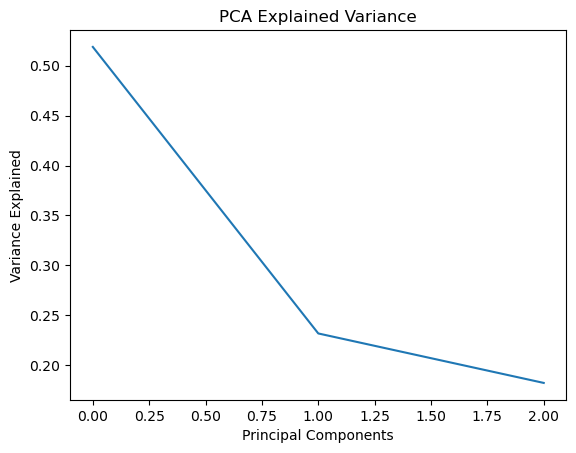

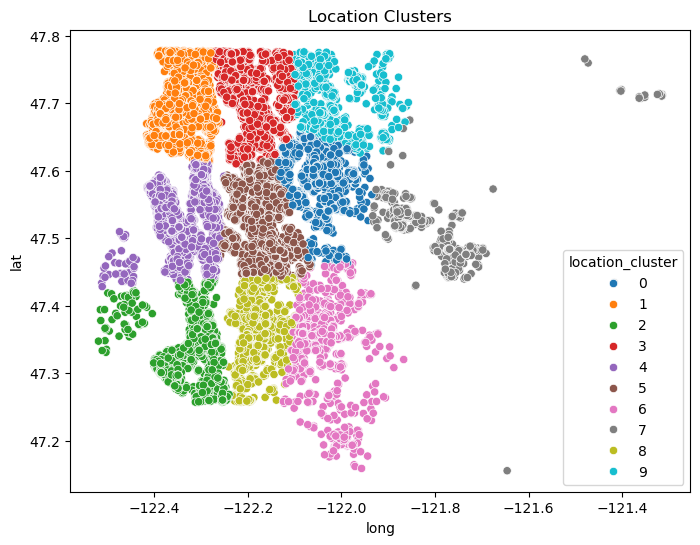

In [47]:
plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(x=data['long'], y=data['lat'], hue=data['location_cluster'], palette='tab10')
plt.title("Location Clusters")
plt.show()

## Duplicates 

In [48]:
print(data.columns[data.columns == 'bathrooms'])
# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]


Index(['bathrooms', 'bathrooms'], dtype='object')


In [49]:
print(data.columns.tolist())
for col in data.columns:
    if 'price' in col:
        print(col)

['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_log', 'sqft_lot_log', 'sqft_lot15_log', 'HouseAge', 'HouseAge_scaled', 'pca1', 'pca2', 'pca3', 'location_cluster', 'sqft_living bedrooms', 'sqft_living bathrooms', 'bedrooms bathrooms']
price_log


# feature engineering

In [50]:
# 1. HouseAge
data['HouseAge'] = 2026 - data['yr_built']

# 2. RenovatedFlag
data['RenovatedFlag'] = np.where(data['yr_renovated'] > 0, 1, 0)

# 3. TotalBathrooms
# If you have a half_bath column, include it; otherwise just use bathrooms
if 'half_bath' in data.columns:
    data['TotalBathrooms'] = data['bathrooms'] + data['half_bath']
else:
    data['TotalBathrooms'] = data['bathrooms']

# 4. PricePerSqFt
data = pd.get_dummies(data, drop_first=True)

# 5. LivingPerBedroom
data['LivingPerBedroom'] = data['sqft_living'] / data['bedrooms']
# Handle division by zero
data['LivingPerBedroom'].replace([np.inf, -np.inf], np.nan, inplace=True)
data['LivingPerBedroom'].fillna(0, inplace=True)

# 6. LuxuryFlag
data['LuxuryFlag'] = np.where((data['grade'] >= 10) | (data['price_log'] > 1_000_000), 1, 0)

# Final check
print(data[['HouseAge','RenovatedFlag','TotalBathrooms',
            'LivingPerBedroom','LuxuryFlag']].head())


   HouseAge  RenovatedFlag  TotalBathrooms  LivingPerBedroom  LuxuryFlag
0        71              0         0.12500        -18.530368           0
1        75              1         0.28125          7.802446           0
2        93              0         0.12500        -35.103321           0
3        61              0         0.37500          0.588789           0
4        39              0         0.25000         -3.206745           0


# feature selection 
- train_test split 
- Randomforest regressor 
- RFE selection techinque


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# 1. Keep only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Target and features
y = numeric_data['price_log']
X = numeric_data.drop(columns=['price_log'])

# 2. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Correlation Filter (ONLY on training data)
train_data = X_train.copy()
train_data['price_log'] = y_train

corr = train_data.corr()['price_log'].sort_values(ascending=False)

selected_corr_features = corr.index[1:25]

print("Correlation-selected features:", list(selected_corr_features))

# 4. Recursive Feature Elimination (RFE)
model_lr = LinearRegression()

selector = RFE(model_lr, n_features_to_select=min(15, len(selected_corr_features)))

selector.fit(X_train[selected_corr_features], y_train)

selected_rfe_features = X_train[selected_corr_features].columns[selector.support_]

print("RFE-selected features:", list(selected_rfe_features))

# 5. RandomForest Feature Importance
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print("Top 15 features by RandomForest:\n", feature_importance.head(15))

# 6. Final Feature Set
final_features = list(
    set(selected_corr_features)
    & set(selected_rfe_features)
    & set(feature_importance.head(15).index)
)

print("Final selected features:", final_features)

# 7. Model Training
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

model = RandomForestRegressor(random_state=42)

model.fit(X_train_final, y_train)

predictions = model.predict(X_test_final)

Correlation-selected features: ['grade', 'sqft_living bedrooms', 'sqft_living bathrooms', 'sqft_living', 'sqft_living15', 'sqft_above', 'LivingPerBedroom', 'pca1', 'TotalBathrooms', 'bathrooms', 'bedrooms bathrooms', 'LuxuryFlag', 'lat', 'view', 'bedrooms', 'floors', 'sqft_basement', 'waterfront', 'sqft_lot', 'sqft_lot_log', 'yr_renovated', 'sqft_lot15', 'RenovatedFlag', 'sqft_lot15_log']
RFE-selected features: ['grade', 'sqft_living bedrooms', 'sqft_living bathrooms', 'sqft_living15', 'TotalBathrooms', 'bedrooms bathrooms', 'lat', 'view', 'bedrooms', 'waterfront', 'sqft_lot', 'sqft_lot_log', 'sqft_lot15', 'RenovatedFlag', 'sqft_lot15_log']
Top 15 features by RandomForest:
 grade                    0.327060
lat                      0.286155
sqft_living bathrooms    0.067742
pca1                     0.054369
LivingPerBedroom         0.041642
sqft_living bedrooms     0.036672
long                     0.035882
sqft_living              0.034105
sqft_living15            0.015355
yr_built   

## Visualization of feature importance (Random forest)

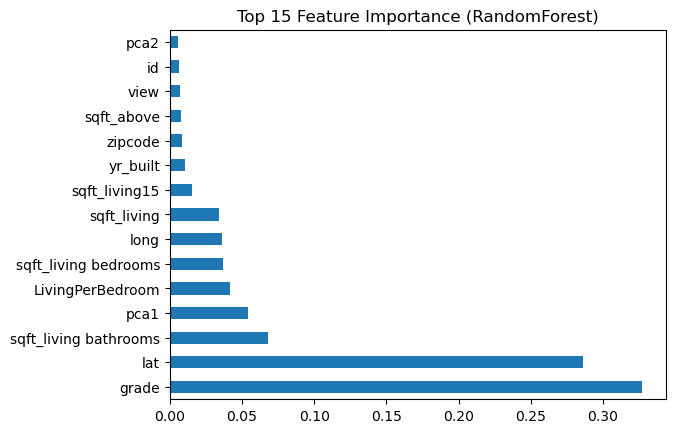

In [52]:
feature_importance.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importance (RandomForest)")
plt.show()

# Cross Validation technique 

In [53]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

model = XGBRegressor()

scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.88883918 0.88592118 0.8903086  0.89217065 0.88697429]
Average Score: 0.8888427794668582


# Hyperparameter Optimization 
- using GridsearchCV

In [54]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.9}


# Model Training and evalution 
Usen models  
- Linear regression 
- decision tree 
- random forest  
- XG-boost 
- lightgbm
### stacking method usen
##### base models 
- linear regression 
- Decision trees 
- Random Forest 
- XGBoost 
- Lightgbm
##### meta model 
- linear regressor 
### Evalution techiques usen  
- MAE 
- RMSE
- r2

In [55]:
import lightgbm
print(lightgbm.__version__)

4.6.0


In [56]:

# Imports
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# Base models for stacking
base_models = [
    ("lr", LinearRegression()),
    ("dt", DecisionTreeRegressor(random_state=42)),
    ("rf", RandomForestRegressor(n_estimators=500, random_state=42)),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )),
    ("lgbm", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=7,
        verbose=-1
    ))
]

# Meta-model for stacking
meta_model = LinearRegression()

# Stacking Regressor
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# All models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=7,
        verbose=-1
    ),
    "Stacking Model": stack_model
}

# -------------------------------
# Train and evaluate models
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train
    trained_models[name] = model
    y_pred = model.predict(X_test)  # Predict
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])
    
    print(f"Model: {name}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print("-"*30)

# -------------------------------
# Convert results to DataFrame and sort by R2
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
results_df = results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("\nModel Comparison (sorted by R2):")
print(results_df)

# -------------------------------
# Best model
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
print("\nFinal Evaluation of Best Model:")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred_best):.4f}")

Model: Linear Regression
MAE : 0.3609
RMSE: 0.4715
R2  : 0.7816
------------------------------
Model: Decision Tree
MAE : 0.3461
RMSE: 0.4843
R2  : 0.7696
------------------------------
Model: Random Forest
MAE : 0.2446
RMSE: 0.3439
R2  : 0.8838
------------------------------
Model: XGBoost
MAE : 0.2216
RMSE: 0.3116
R2  : 0.9046
------------------------------
Model: LightGBM
MAE : 0.2238
RMSE: 0.3123
R2  : 0.9042
------------------------------
Model: Stacking Model
MAE : 0.2205
RMSE: 0.3090
R2  : 0.9062
------------------------------

Model Comparison (sorted by R2):
               Model       MAE      RMSE  R2 Score
0     Stacking Model  0.220471  0.308988  0.906209
1            XGBoost  0.221552  0.311644  0.904590
2           LightGBM  0.223756  0.312275  0.904203
3      Random Forest  0.244615  0.343913  0.883809
4  Linear Regression  0.360896  0.471540  0.781569
5      Decision Tree  0.346060  0.484273  0.769613

Best Model: Stacking Model

Final Evaluation of Best Model:
MAE : 0.

# Visualization the actual and predicted prices 

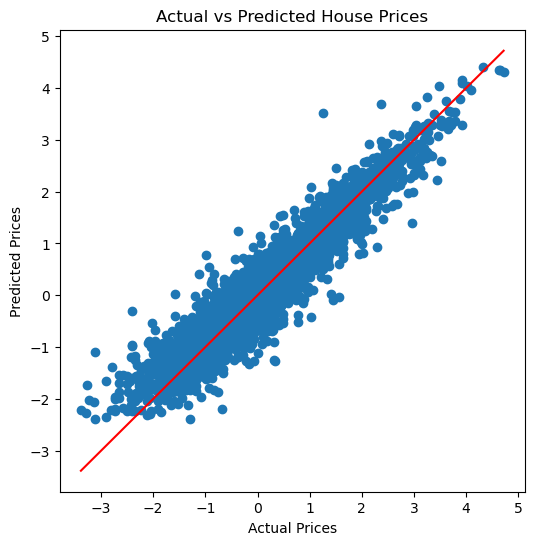

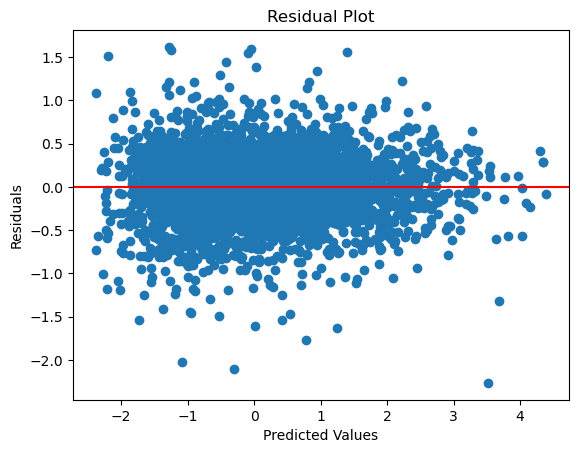

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

residuals = y_test - y_pred_best

plt.scatter(y_pred_best, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()